# Import Modul

In [1]:
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
from wordcloud import WordCloud

# Load Data



In [8]:
url_github = "https://raw.githubusercontent.com/BatNotFound/UTS-Andat-TT/refs/heads/main/Suicide_Ideation_Dataset(Twitter-based).csv"

In [9]:
df = pd.read_csv(url_github)

df.head()

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@Alexia You want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


# EDA (Exploratory Data Analysis)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1787 entries, 0 to 1786
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Tweet    1785 non-null   object
 1   Suicide  1787 non-null   object
dtypes: object(2)
memory usage: 28.1+ KB


In [11]:
df["Suicide"].value_counts()

,count
Suicide,
Not Suicide post,1127
Potential Suicide post,660


/tmp/ipykernel_678/2982676802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Suicide', palette='Set2')


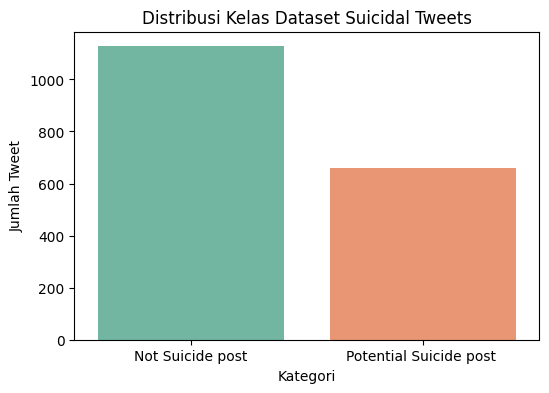

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Suicide', palette='Set2')
plt.title("Distribusi Kelas Dataset Suicidal Tweets")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Tweet")
plt.show()

In [13]:
# Mengecek missing value
missing_values = df.isnull().sum()

missing_values

,0
Tweet,2
Suicide,0


In [14]:
# Menghapus missing value
if missing_values.sum() > 0:
    df = df.dropna()
    print("Baris yang kosong telah dihapus.")
else:
    print("Tidak ada missing values.")

Baris yang kosong telah dihapus.


In [15]:
# Mengecek data yang duplikat
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(8)

In [16]:
# Menghapus data duplikat
if duplicate_count.sum() > 0:
    df = df.drop_duplicates()
    print("Data duplikat telah dihapus")
else:
    print("Tidak ada data duplikat")

Data duplikat telah dihapus


Suicide
Not Suicide post           63.25%
Potential Suicide post     36.75%
Name: proportion, dtype: object


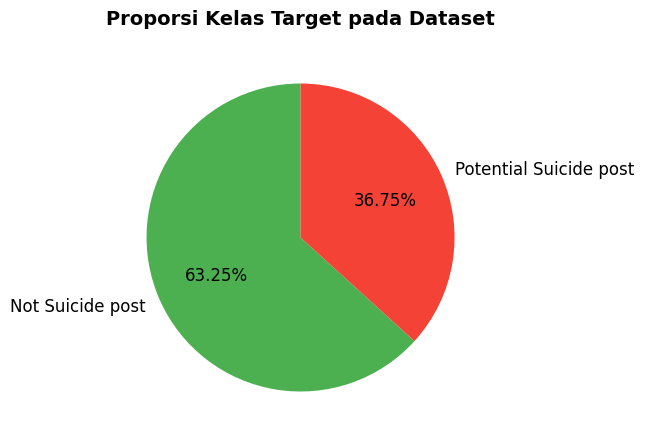

In [17]:
# Menghitung persentase sebaran tweet
proporsi = df["Suicide"].value_counts(normalize=True) * 100

print(proporsi.round(2).astype(str) + "%")

plt.figure(figsize=(5,5))

plt.pie(proporsi,
        labels=proporsi.index,
        autopct='%1.2f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90,
        explode=(0, 0),
        shadow=False,
        textprops={'fontsize': 12})

plt.title('Proporsi Kelas Target pada Dataset', fontsize=14, fontweight='bold', pad=15)
plt.show()

Rata-rata jumlah kata per tweet: 
Suicide
Not Suicide post           12.99
Potential Suicide post     29.55
Name: Jumlah_Kata, dtype: float64


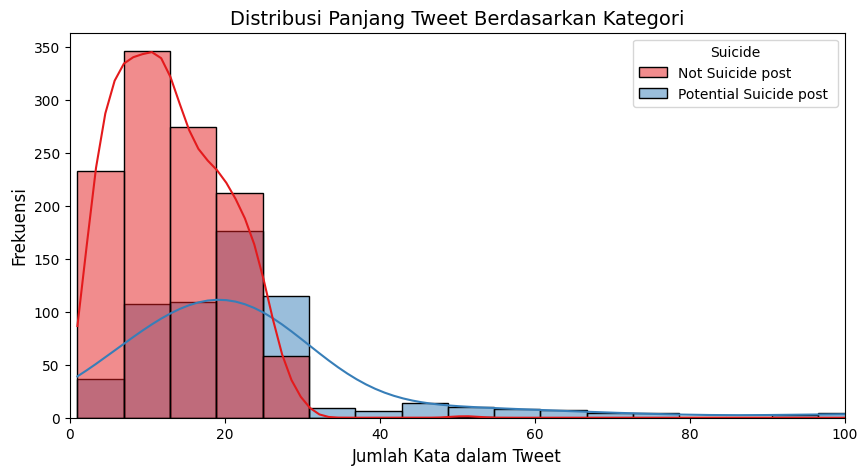

In [18]:
# Analisis panjang teks dengan menghitung kata dalam setiap tweet
df["Jumlah_Kata"] = df["Tweet"].apply(lambda x: len(str(x).split()))

rata_rata = df.groupby("Suicide")["Jumlah_Kata"].mean()
print("Rata-rata jumlah kata per tweet: ")
print(rata_rata.round(2))

plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Jumlah_Kata", hue="Suicide", kde=True, bins=40, palette="Set1")
plt.title("Distribusi Panjang Tweet Berdasarkan Kategori", fontsize=14)
plt.xlabel("Jumlah Kata dalam Tweet", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.xlim(0, 100)
plt.show()

# Text Preprocessing

In [19]:
stop_words = set(stopwords.words("english"))

kata_penting = {
    "i", "me", "my", "myself",
    "no", "not", "nor", "don", "don't", "ain", "ain't", "aren", "aren't", # Kata negatif
    "couldn", "couldn't", "didn", "didn't", "doesn", "doesn't",
    "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't",
    "isn", "isn't", "mightn", "mightn't", "mustn", "mustn't",
    "needn", "needn't", "shan", "shan't", "shouldn", "shouldn't",
    "wasn", "wasn't", "weren", "weren't", "won", "won't", "wouldn", "wouldn't"
}

stop_words = stop_words - kata_penting

In [20]:
# Membersihkan Tweet
def clean_text(text):
    text = str(text)

    text = text.lower() # Case Folding

    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE) # Menghapus link URL
    text = re.sub(r"\@\w+", "", text) # Menghapus mention (@username)

    text = re.sub(r"[^a-z\s]", " ", text) # Menghapus tanda baca, angka, dan simbol; hanya menyisakan huruf alfabet (a-z) dan spasi

    kata_kata = text.split()
    kata_bersih = [kata for kata in kata_kata if kata not in stop_words] # Menghapus kata yang tidak ada di custom stopwords

    return " ".join(kata_bersih)

In [21]:
df["Cleaned_Tweet"] = df["Tweet"].apply(clean_text)

df[["Tweet", "Cleaned_Tweet"]].head(20)

,Tweet,Cleaned_Tweet
0,making some lunch,making lunch
1,@Alexia You want his money.,want money
2,@dizzyhrvy that crap took me forever to put to...,crap took me forever put together i going go s...
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,kiwitweets hey jer since start twittering
4,Trying out &quot;Delicious Library 2&quot; wit...,trying quot delicious library quot mixed resul...
5,"@ValenValdez Oh, that's good to hear. But is i...",oh good hear already continue holy week
6,@mcm180 u've got a list for fellow #hotties? Y...,u got list fellow hotties gonna share one amigo
7,@jakepaul @jamescharles @LoganPaul Just becaus...,shane made series doesnt mean people take seri...
8,time for some warsaw beer garden chilling,time warsaw beer garden chilling
9,I hate my life lmao I hope I die soon or sumn ...,i hate my life lmao i hope i die soon sumn i t...


In [22]:
lemmatizer = WordNetLemmatizer()

def lemmatization(text):
    text = str(text)

    kata_kata = text.split()

    kata_lemmatized = [lemmatizer.lemmatize(kata) for kata in kata_kata]

    return " ".join(kata_lemmatized)

In [23]:
df["Lemmatized_Tweet"] = df["Cleaned_Tweet"].apply(lemmatization)

df[["Tweet", "Cleaned_Tweet", "Lemmatized_Tweet"]].head(10)

,Tweet,Cleaned_Tweet,Lemmatized_Tweet
0,making some lunch,making lunch,making lunch
1,@Alexia You want his money.,want money,want money
2,@dizzyhrvy that crap took me forever to put to...,crap took me forever put together i going go s...,crap took me forever put together i going go s...
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,kiwitweets hey jer since start twittering,kiwitweets hey jer since start twittering
4,Trying out &quot;Delicious Library 2&quot; wit...,trying quot delicious library quot mixed resul...,trying quot delicious library quot mixed resul...
5,"@ValenValdez Oh, that's good to hear. But is i...",oh good hear already continue holy week,oh good hear already continue holy week
6,@mcm180 u've got a list for fellow #hotties? Y...,u got list fellow hotties gonna share one amigo,u got list fellow hotties gonna share one amigo
7,@jakepaul @jamescharles @LoganPaul Just becaus...,shane made series doesnt mean people take seri...,shane made series doesnt mean people take seri...
8,time for some warsaw beer garden chilling,time warsaw beer garden chilling,time warsaw beer garden chilling
9,I hate my life lmao I hope I die soon or sumn ...,i hate my life lmao i hope i die soon sumn i t...,i hate my life lmao i hope i die soon sumn i t...


# Feature Engineering

In [24]:
df = df.dropna(subset=["Lemmatized_Tweet"])

In [25]:
X_text = df["Lemmatized_Tweet"]
y_label = df["Suicide"]

In [26]:
encoder = LabelEncoder()
y = encoder.fit_transform(y_label)

In [27]:
# Mapping kelas target
for nama_kelas, nilai_angka in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"'{nama_kelas}' diubah menjadi representasi angka: {nilai_angka}")

'Not Suicide post' diubah menjadi representasi angka: 0
'Potential Suicide post ' diubah menjadi representasi angka: 1


In [28]:
# Mengubah teks menjadi matriks angka
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X_text) # Mengubah (fit and transform) teks menjadi matriks

In [29]:
print(f"Ada {X.shape[0]} jumlah tweet yang diproses")
print(f"Ada {X.shape[1]} kata (fitur) unik yang digunakan untuk training")

Ada 1777 jumlah tweet yang diproses
Ada 4431 kata (fitur) unik yang digunakan untuk training


# Pembuatan Model

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah data training: {X_train.shape[0]} tweet")
print(f"Jumlah data test: {X_test.shape[0]} tweet")

Jumlah data training: 1421 tweet
Jumlah data test: 356 tweet


In [31]:
model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

MultinomialNB()

# Evaluasi Model

In [32]:
y_pred = model_nb.predict(X_test) # Meminta model menebak label pada Data Test

In [33]:
# Menghitung accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 90.17%


In [34]:
# Classification Report
nama_target = encoder.classes_
print(classification_report(y_test, y_pred, target_names=nama_target))

                         precision    recall  f1-score   support

       Not Suicide post       0.92      0.92      0.92       225
Potential Suicide post        0.86      0.87      0.87       131

               accuracy                           0.90       356
              macro avg       0.89      0.90      0.89       356
           weighted avg       0.90      0.90      0.90       356



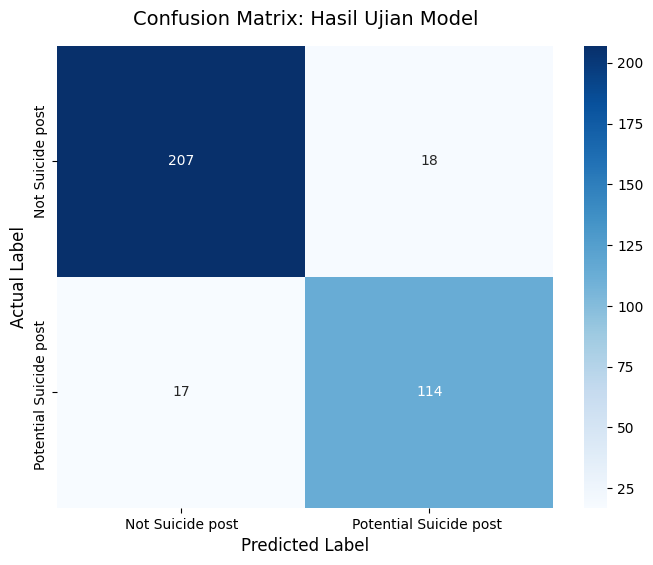

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=nama_target,
            yticklabels=nama_target)

plt.title("Confusion Matrix: Hasil Ujian Model", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.show()

In [36]:
# Memisahkan data berdasarkan kategori
not_suicide_text = " ".join(df[df["Suicide"].str.contains("Not Suicide")]["Lemmatized_Tweet"].astype(str))
potential_text = " ".join(df[df["Suicide"].str.contains("Potential Suicide")]["Lemmatized_Tweet"].astype(str))

In [37]:
# Membuat Word Cloud
wc_not_suicide = WordCloud(width=800, height=800,
                           background_color='white',
                           colormap='Greens',
                           max_words=100).generate(not_suicide_text)

wc_potential = WordCloud(width=800, height=800,
                         background_color='white',
                         colormap='Reds',
                         max_words=100).generate(potential_text)

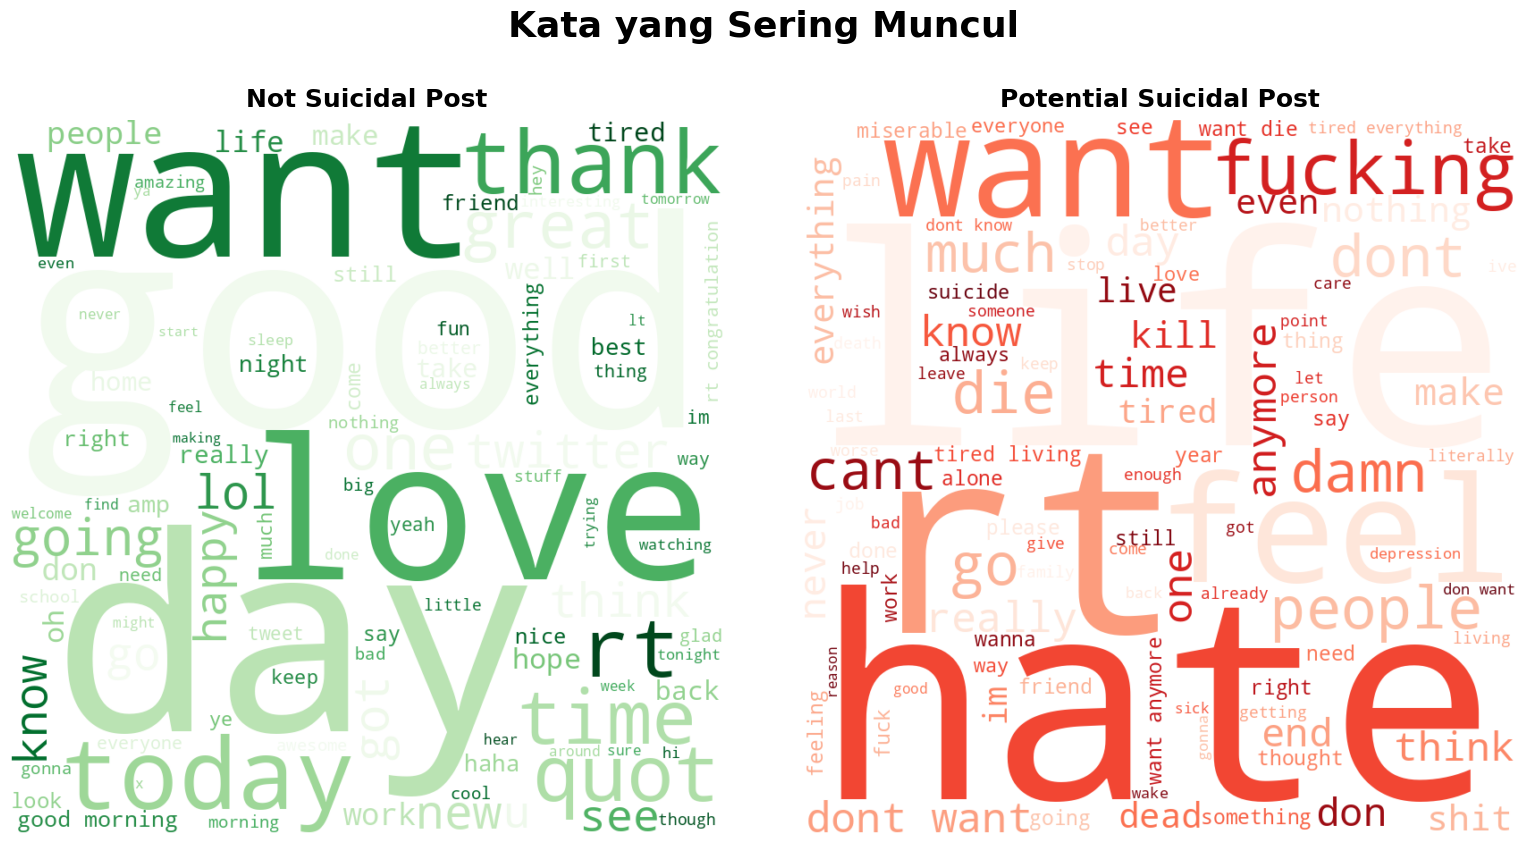

In [38]:
plt.figure(figsize=(16, 8))
plt.suptitle("Kata yang Sering Muncul", fontsize=26, fontweight="bold", y=1.05)

# Not Suicide post
plt.subplot(1,2,1)
plt.imshow(wc_not_suicide, interpolation="bilinear")
plt.title("Not Suicidal Post", fontsize=18, fontweight="bold", pad=10)
plt.axis("off")

# Potential Suicide post
plt.subplot(1,2,2)
plt.imshow(wc_potential, interpolation="bilinear")
plt.title("Potential Suicidal Post", fontsize=18, fontweight="bold", pad=10)
plt.axis("off")

plt.tight_layout()
plt.show()